In [ ]:

# ! pip install torchtext==0.6.0 --user
base_file_name       = "Transformer-124"
train_file_name      = base_file_name+"-train.csv"
test_file_name       = base_file_name+"-test.csv"
validation_file_name = base_file_name+"-validation.csv"
model_file_name      = base_file_name+"-model.pt"

batch_size_start = 128#32  # original_value = 64
pos_weight = 1 # the value of pos_weight to resolve impalancing  original_value = .29
# learning rate
lr_v = 0.00007 # 1e-4 , 0.00007, 1e-5, 0.00005
n_epoch_number = 10
DROPOUT = 0.6 # 0.5 , 0.45
# reduced_dimensions = 768
random_s = 3


In [ ]:
import torch

import pandas as pd
from torchtext.data import Field, BucketIterator, TabularDataset,LabelField
from sklearn.model_selection import train_test_split
import random
import numpy as np
from transformers import BertTokenizer
import torch.nn.functional as F

from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import cohen_kappa_score

import re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WordPunctTokenizer
from nltk.tokenize import TweetTokenizer
from nltk.tokenize import LegalitySyllableTokenizer
from nltk import word_tokenize
# from nltk.tokenize import word_tokenize
import contractions
from nltk.corpus import words
from torchtext import data
LP = LegalitySyllableTokenizer(words.words())

from transformers import BertTokenizer, BertModel
# from transformers import BertTokenizer, BertModel

from transformers import BertTokenizer, BertModel
# from transformers import BertTokenizer, BertModel
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
from textblob import TextBlob

import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw
import nlpaug.augmenter.sentence as nas
import nlpaug.flow as nafc

from nlpaug.util import Action

import os
import logging

import numpy as np
from tqdm import trange
import tensorflow as tf

from utils import *
# from network import Network
# from statistic import Statistic

In [ ]:

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [ ]:
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# # tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')
# len(tokenizer.vocab)

BERT_MODEL = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
len(tokenizer.vocab)

50265

In [ ]:
init_token = tokenizer.cls_token
eos_token = tokenizer.sep_token
pad_token = tokenizer.pad_token
unk_token = tokenizer.unk_token

print(init_token, eos_token, pad_token, unk_token)

<s> </s> <pad> <unk>


In [ ]:
init_token_idx = tokenizer.convert_tokens_to_ids(init_token)
eos_token_idx = tokenizer.convert_tokens_to_ids(eos_token)
pad_token_idx = tokenizer.convert_tokens_to_ids(pad_token)
unk_token_idx = tokenizer.convert_tokens_to_ids(unk_token)

print(init_token_idx, eos_token_idx, pad_token_idx, unk_token_idx)

0 2 1 3


In [ ]:
init_token_idx = tokenizer.cls_token_id
eos_token_idx = tokenizer.sep_token_id
pad_token_idx = tokenizer.pad_token_id
unk_token_idx = tokenizer.unk_token_id

print(init_token_idx, eos_token_idx, pad_token_idx, unk_token_idx)

0 2 1 3


In [ ]:
# max_input_length = tokenizer.max_model_input_sizes['bert-base-uncased']
# # max_input_length = tokenizer.max_model_input_sizes['bert-large-uncased']
# print(max_input_length)

max_input_length = tokenizer.max_model_input_sizes[BERT_MODEL]
print(max_input_length)

512


In [ ]:
def tokenize_and_cut(sentence):
    tokens = tokenizer.tokenize(sentence)
    tokens = tokens[:max_input_length-2]
    return tokens

In [ ]:
from torchtext import data

Text = data.Field(batch_first = True,
                  use_vocab = False,
                  tokenize = tokenize_and_cut,
                  preprocessing = tokenizer.convert_tokens_to_ids,
                  init_token = init_token_idx,
                  eos_token = eos_token_idx,
                  pad_token = pad_token_idx,
                  unk_token = unk_token_idx,
                  include_lengths = True)

Urgency = LabelField(sequential=False, use_vocab=False,dtype = torch.float)
fields = {"Text": ("t", Text), "Urgency": ("ur", Urgency)}

In [ ]:
def sentimentAnalysis (document):

    vs = analyzer.polarity_scores(document)
#     res = TextBlob(document)
#     document = str(res)+ " " + document
# #     document = str(vs['neg'])+ " " + str(vs['pos'])+ " " +str(vs['compound'])+ " " + document
    if vs['compound'] >= 0.05:
        document = "0 " + document # "positive " + document
    elif vs['compound'] <= -0.05:
        document = "1 " + document # "negative " + document
    else:
        document = "1 " + document  #  "natural " + document

    return document

In [ ]:
def preprocess (document):
#     urgentList = ["?", "do no understand", "have to", "could you please", "certificate", "i have no idea", "these problems",
#              "i am still waiting", "i'm not confused", "i didn't understand", "same issue", "doesn't match",
#              "challenge", "concern", "however", "not clear", "would like", "can we get", "may i make", "couldn't find"
#             , "i was sad", "access the videos", "how do you", "but i cannot", "i don't see", "can't find", "how do you suggest"
#              , "tech team", "instructor", "assignment", "how long", "assessments", " l have the same", "progress was not funtioning"

#                  ]

#     document = document.lower()
#     for simpol in urgentList:
#         if simpol in document:
#             document = "question " + document # document = "question " + document
#             break
#     if "question " not in document:
#         document = "answer " + document


#     if "?" in document:
#         document = "1 " + document
#     else:
#         document = "0 " + document
    if "?" in document:
        document = "question " + document # document = "question " + document
    else:
        document = "answer " + document

    return document

In [ ]:
# aug = nas.AbstSummAug(model_path='t5-base') # , num_beam=3

aug_1 = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
aug_2 = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="substitute")
aug_3 = naw.ContextualWordEmbsAug(model_path='distilbert-base-uncased', action="substitute")
aug_4 = naw.ContextualWordEmbsAug(model_path='roberta-base', action="substitute")
aug_5 = naw.SynonymAug(aug_src='wordnet')

def augment_text(df):
    new_text=[]
    ##selecting the minority class samples
    df_n=df[df.Urgency==1].reset_index(drop=True)
    ## data augmentation loop
    for i in range(len(df_n)):
#     for i in range(10):
#         print (i)
        text = df_n.loc[i, "Text"]
        augmented_text_1 = aug_1.augment(text)
        augmented_text_n_1 = "".join(augmented_text_1)
        tokens = tokenizer.tokenize(augmented_text_n_1)
        if (len(tokens)>=4):
            new_text.append(augmented_text_1)

        augmented_text_2 = aug_2.augment(text)
        augmented_text_n_2 = "".join(augmented_text_2)
        tokens = tokenizer.tokenize(augmented_text_n_2)
        if (len(tokens)>=4):
            new_text.append(augmented_text_2)

        augmented_text_3 = aug_3.augment(text)
        augmented_text_n_3 = "".join(augmented_text_3)
        tokens = tokenizer.tokenize(augmented_text_n_3)
        if (len(tokens)>=4):
            new_text.append(augmented_text_3)

        augmented_text_4 = aug_4.augment(text)
        augmented_text_n_4 = "".join(augmented_text_4)
        tokens = tokenizer.tokenize(augmented_text_n_4)
        if (len(tokens)>=4):
            new_text.append(augmented_text_4)

        augmented_text_5 = aug_5.augment(text)
        augmented_text_n_5 = "".join(augmented_text_5)
        tokens = tokenizer.tokenize(augmented_text_n_5)
        if (len(tokens)>=4):
            new_text.append(augmented_text_5)

    new=pd.DataFrame({'Text':new_text,'Urgency':1})
#     df=shuffle(df.append(new).reset_index(drop=True))
    df=df.append(new).reset_index(drop=True)
    return df


# aug = naw.ContextualWordEmbsAug(model_path='bert-base-uncased', action="insert")
# def augment_text(df):
#     new_text=[]
#     ##selecting the minority class samples
#     df_n=df[df.Urgency==1].reset_index(drop=True)
#     ## data augmentation loop
#     for i in range(len(df_n)):
# #     for i in range(100):
# #         print (i)
#         text = df_n.loc[i, "Text"]
#         augmented_text = aug.augment(text)
#         augmented_text_n = "".join(augmented_text)
#         tokens = tokenizer.tokenize(augmented_text_n)
# #         tokens = word_tokenize(augmented_text)
#         if (len(tokens)>=4):
#             new_text.append(augmented_text)

#     new=pd.DataFrame({'Text':new_text,'Urgency':1})
# #     df=shuffle(df.append(new).reset_index(drop=True))
#     df=df.append(new).reset_index(drop=True)
#     return df

In [ ]:
# GROUP A
# df =  pd.read_excel('D:\\ahmedFarouk\\MstanfordMOOCForumPostsSet.xlsx') #'mystanfordMOOCForumPostsSet.xlsx'
df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
df["Text"] = df["Text"].astype(str)
df["Text"] = df["Text"].apply(preprocess)
# df["Text"] = df["Text"].astype(str) #+" "+df["CourseType"].astype(str) #+df["post_type"].astype(str)
df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str)
# df['Text']=df["course_display_name"].astype(str)+" "+df['Text']  # df["course_display_name"].astype(str)+" "+
# df["Text"] = df["Text"].apply(preprocess)
df["Text"] = df["Text"].apply(sentimentAnalysis)
df = df.loc[:, ['Text', 'Urgency']]
df.loc[df['Urgency']<4, ['Urgency']]=0
df.loc[df['Urgency']>=4, ['Urgency']]=1
print ('size of all data = ', df.shape)
train, test = train_test_split(df, test_size=0.2,stratify=df['Urgency'], random_state = random_s)
test,valid = train_test_split(test, test_size=0.5,stratify=test['Urgency'],random_state = random_s)
print ('size of all data = ', test.shape,valid.shape,train.shape)

# data augementation
# train = augment_text(train)
# print ('size of all data after aug = ', test.shape,valid.shape,train.shape)
# print (train.head())
train.to_csv("cnnTrain.csv", index=False) # cnnTrain_augmentation.csv
valid.to_csv("cnnValid.csv", index=False)
test.to_csv("cnnTest.csv", index=False)
# df.to_csv("total.csv", index=False)

size of all data =  (29597, 2)
size of all data =  (2960, 2) (2960, 2) (23677, 2)


In [ ]:
# # Group B
# df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
# # df["Text"] = df["CourseType"].astype(str) +" "+ df["Text"].astype(str)
# # df["Text"] = df["Text"].astype(str)
# df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str)
# # df['Text']=df['Text'].apply(preprocess)
# df["course_display_name"].unique()
# print(df.shape)
# df1_test = df.loc[(df["course_display_name"] == 'HumanitiesScience/StatLearning/Winter2014') |
#        (df["course_display_name"] == 'Medicine/HRP258/Statistics_in_Medicine') |
#        (df["course_display_name"] == 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') ]

# df1_train = df.loc[(df["course_display_name"] != 'HumanitiesScience/StatLearning/Winter2014') &
#        (df["course_display_name"] != 'Medicine/HRP258/Statistics_in_Medicine') &
#        (df["course_display_name"] != 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') &
#        (df["course_display_name"] != 'Education/EDUC115N/How_to_Learn_Math')]

# df1_train = df1_train.loc[:, ['Text', 'Urgency']]
# df1_train.loc[df1_train['Urgency']<4, ['Urgency']]=0
# df1_train.loc[df1_train['Urgency']>=4, ['Urgency']]=1

# df1_test = df1_test.loc[:, ['Text', 'Urgency']]
# df1_test.loc[df1_test['Urgency']<4, ['Urgency']]=0
# df1_test.loc[df1_test['Urgency']>=4, ['Urgency']]=1
# print('df1',df1_test.shape,df1_train.shape)

# df2 =  df.loc[(df["course_display_name"] == 'Education/EDUC115N/How_to_Learn_Math')]
# print(df2.shape)
# df2 = df2.loc[:, ['Text', 'Urgency']]
# df2.loc[df2['Urgency']<4, ['Urgency']]=0
# df2.loc[df2['Urgency']>=4, ['Urgency']]=1

# df2_train, df2_test = train_test_split(df2, test_size=0.2,stratify=df2['Urgency'])


# train = pd.concat([df1_train, df2_train])
# test = pd.concat([df1_test, df2_test])
# test,valid = train_test_split(test, test_size=0.5,stratify=test['Urgency'])
# print('Final',train.shape,test.shape,valid.shape)

# train.to_csv("cnnTrain.csv", index=False)
# valid.to_csv("cnnValid.csv", index=False)
# test.to_csv("cnnTest.csv", index=False)

In [ ]:
# # Group C
# df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
# # df["Text"] = df["Text"].astype(str)
# # df["Text"] = df["Text"].apply(preprocess)
# # # df["Text"] = df["CourseType"].astype(str) +" "+ df["Text"].astype(str)
# # df["Text"] = df["Text"].astype(str)
# # df['Text']=df['Text']

# df["Text"] = df["Text"].astype(str)
# df["Text"] = df["Text"].apply(preprocess)
# # df["Text"] = df["Text"].astype(str) #+" "+df["CourseType"].astype(str) #+df["post_type"].astype(str)
# df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str)
# # df['Text']=df["course_display_name"].astype(str)+" "+df['Text']  # df["course_display_name"].astype(str)+" "+
# # df["Text"] = df["Text"].apply(preprocess)
# df["Text"] = df["Text"].apply(sentimentAnalysis)

# df["course_display_name"].unique()
# print(df.shape)
# test = df.loc[(df["course_display_name"] == 'HumanitiesScience/Stats216/Winter2014') |
#        (df["course_display_name"] == 'HumanitiesSciences/EP101/Environmental_Physiology') |
#        (df["course_display_name"] == 'HumanitiesScience/StatLearning/Winter2014')|
#        (df["course_display_name"] == 'HumanitiesSciences/Econ1V/Summer2014') |
#        (df["course_display_name"] == 'HumanitiesSciences/Econ-1/Summer2014') |
#        (df["course_display_name"] ==  'GlobalHealth/WomensHealth/Winter2014')]


# train = df.loc[(df["course_display_name"] =='Medicine/SciWrite/Fall2013') |
#        (df["course_display_name"] == 'Medicine/HRP258/Statistics_in_Medicine') |
#        (df["course_display_name"] == 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') |
#        (df["course_display_name"] == 'Medicine/MedStats/Summer2014') |
#        (df["course_display_name"] == 'Education/EDUC115N/How_to_Learn_Math')]

# train = train.loc[:, ['Text', 'Urgency']]
# train.loc[train['Urgency']<4, ['Urgency']]=0
# train.loc[train['Urgency']>=4, ['Urgency']]=1

# test = test.loc[:, ['Text', 'Urgency']]
# test.loc[test['Urgency']<4, ['Urgency']]=0
# test.loc[test['Urgency']>=4, ['Urgency']]=1
# test,valid = train_test_split(test, test_size=0.7,stratify=test['Urgency'])
# print(test.shape,valid.shape,train.shape)

# train.to_csv("cnnTrain.csv", index=False)
# valid.to_csv("cnnValid.csv", index=False)
# test.to_csv("cnnTest.csv", index=False)

In [ ]:
# # Group C
# df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
# # df["Text"] = df["Text"].astype(str)
# # df["Text"] = df["Text"].apply(preprocess)
# # # df["Text"] = df["CourseType"].astype(str) +" "+ df["Text"].astype(str)
# # df["Text"] = df["Text"].astype(str)
# # df['Text']=df['Text']

# df["Text"] = df["Text"].astype(str)
# df["Text"] = df["Text"].apply(preprocess)
# # df["Text"] = df["Text"].astype(str) #+" "+df["CourseType"].astype(str) #+df["post_type"].astype(str)
# df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str)
# # df['Text']=df["course_display_name"].astype(str)+" "+df['Text']  # df["course_display_name"].astype(str)+" "+
# # df["Text"] = df["Text"].apply(preprocess)
# df["Text"] = df["Text"].apply(sentimentAnalysis)

# df["course_display_name"].unique()
# print(df.shape)
# test = df.loc[(df["course_display_name"] == 'HumanitiesScience/Stats216/Winter2014') |
#        (df["course_display_name"] == 'HumanitiesSciences/EP101/Environmental_Physiology') |
#        (df["course_display_name"] == 'HumanitiesScience/StatLearning/Winter2014')|
#        (df["course_display_name"] == 'HumanitiesSciences/Econ1V/Summer2014') |
#        (df["course_display_name"] == 'HumanitiesSciences/Econ-1/Summer2014') |
#        (df["course_display_name"] ==  'GlobalHealth/WomensHealth/Winter2014')]


# train = df.loc[(df["course_display_name"] =='Medicine/SciWrite/Fall2013') |
#        (df["course_display_name"] == 'Medicine/HRP258/Statistics_in_Medicine') |
#        (df["course_display_name"] == 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') |
#        (df["course_display_name"] == 'Medicine/MedStats/Summer2014') |
#        (df["course_display_name"] == 'Education/EDUC115N/How_to_Learn_Math')]

# train = train.loc[:, ['Text', 'Urgency']]
# train.loc[train['Urgency']<4, ['Urgency']]=0
# train.loc[train['Urgency']>=4, ['Urgency']]=1

# test = test.loc[:, ['Text', 'Urgency']]
# test.loc[test['Urgency']<4, ['Urgency']]=0
# test.loc[test['Urgency']>=4, ['Urgency']]=1
# train,valid = train_test_split(train, test_size=0.1,stratify=train['Urgency'])
# print(test.shape,valid.shape,train.shape)

# train.to_csv("cnnTrain.csv", index=False)
# valid.to_csv("cnnValid.csv", index=False)
# test.to_csv("cnnTest.csv", index=False)

In [ ]:
train_data, valid_data, test_data = TabularDataset.splits(path = "", #path = 'D:\\ahmedFarouk\\proposal1_cnn\\'
                                                          train="cnnTrain_augmentation.csv",  # cnnTrain_augmentation.csv cnnTrain.csv
                                                          validation="cnnValid.csv",
                                                          test="cnnTest.csv", format="csv",
                                                          fields=fields)

Token indices sequence length is longer than the specified maximum sequence length for this model (525 > 512). Running this sequence through the model will result in indexing errors


In [ ]:

print(f"Number of training examples: {len(train_data)}")
print(f"Number of validation examples: {len(valid_data)}")
print(f"Number of testing examples: {len(test_data)}")

Number of training examples: 49347
Number of validation examples: 2960
Number of testing examples: 2960


In [ ]:
# print(vars(train_data.examples[6]))
# tokens = tokenizer.convert_ids_to_tokens(vars(train_data.examples[6])['t'])
# print(tokens)

In [ ]:
BATCH_SIZE = batch_size_start

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print (device)
train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,sort_within_batch = True,
    sort_key = lambda x: len(x.t),
    device = device)



# bert = BertModel.from_pretrained('bert-base-uncased')
# # bert = BertModel.from_pretrained('bert-large-uncased')
bert = AutoModel.from_pretrained(BERT_MODEL)

cuda


Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.decoder.weight', 'lm_head.layer_norm.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.bias']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [ ]:
import torch.nn as nn

class BERTGRUSentiment(nn.Module):
    def __init__(self, bert, hidden_dim, output_dim, n_layers, bidirectional, dropout):

        super().__init__()

        self.bert = bert
        embedding_dim = bert.config.to_dict()['hidden_size']
#         declar normalization for bert
        self.norm_embedding = nn.LayerNorm(embedding_dim)
#         declar Bi-LSTM
        self.rnn = nn.LSTM(embedding_dim,
                           hidden_dim,
                           num_layers=n_layers,
                           bidirectional=bidirectional,
                           dropout=dropout)
#         declar CNN - we have 4
        self.conv_0 = nn.Conv2d(in_channels = 1,
                                out_channels = n_filters,
                                kernel_size = (filter_sizes[0], embedding_dim))
        self.conv_1 = nn.Conv2d(in_channels = 1,
                                out_channels = n_filters,
                                kernel_size = (filter_sizes[1], embedding_dim))
        self.conv_2 = nn.Conv2d(in_channels = 1,
                                out_channels = n_filters,
                                kernel_size = (filter_sizes[2], embedding_dim))
        self.conv_3 = nn.Conv2d(in_channels = 1,
                                out_channels = n_filters,
                                kernel_size = (filter_sizes[3], embedding_dim))
#         declar self attention
        self.attention1 = torch.nn.MultiheadAttention(n_filters*4, 8, dropout=0.4)#
#         declar normalization after CNN
        self.norm1 = nn.LayerNorm(n_filters*4)
#         declar attention after LSTM
        self.attention4 = torch.nn.MultiheadAttention(hidden_dim*2, 8, dropout=0.4)#
#         declar normalization after LSTM
        self.norm4 = nn.LayerNorm(hidden_dim*2)
#         self.attention3 = torch.nn.MultiheadAttention(1536, 8)
#         self.attention4 = torch.nn.MultiheadAttention(1792, 8)

#         self.fc1 = nn.Linear(int (len(filter_sizes) * n_filters/2) , 1) # output_dim
#         self.fc2 = nn.Linear(int (len(filter_sizes) * n_filters/2) , 1) # output_dim
#         self.fc3 = nn.Linear(int (len(filter_sizes) * n_filters/2) , 1) # output_dim
#         self.fc4 = nn.Linear(n_filters + hidden_dim * 2 , 1) # output_dim

#         self.fc = nn.Linear(len(filter_sizes) * n_filters + hidden_dim * 2, output_dim) # output_dim
        self.attention5 = torch.nn.MultiheadAttention(n_filters*2+hidden_dim*2, 8, dropout=0.4)#
        self.norm5 = nn.LayerNorm(n_filters*2+hidden_dim*2)
        self.fc = nn.Linear(n_filters*2+hidden_dim*2, output_dim) # output_dim

        self.dropout = nn.Dropout(dropout)

    def forward(self, text, text_lengths):
#         #text = [batch size, sent len]
        with torch.no_grad():
            embedded_all_layers = self.bert(text, output_hidden_states=True)[2]
#           embedded = self.bert(text)[0]
        embedded = embedded_all_layers[11]
#       normalzing the embedding layer
#         embedded = self.norm_embedding(embedded)
#         print('shape of embedding output ', embedded.shape)
        embedded_u = embedded.unsqueeze(1)
#         print('shape of embedding output afterunsqueeze ', embedded.shape)

        #embedded = [sent len, batch size, emb dim]
        #pack sequence
#         packed_embedded = nn.utils.rnn.pack_padded_sequence(conved_fs, text_lengths)  # original line of packed input
#         start change 1 to apply emdding directly to bilstm
        embedded_p = embedded.permute(1, 0, 2)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded_p, text_lengths)
#         end of change 1
#         print ('packed_embedded = ', packed_embedded.)
        packed_output, (hidden, cell) = self.rnn(packed_embedded)
#         print ('hidden shape = ', hidden.shape)
        #unpack sequence
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
#         print ('shape of output = ', output.shape )
        #output = [sent len, batch size, hid dim * num directions]
        #output over padding tokens are zero tensors
        #hidden = [num layers * num directions, batch size, hid dim]
        #cell = [num layers * num directions, batch size, hid dim]
        #concat the final forward (hidden[-2,:,:]) and backward (hidden[-1,:,:]) hidden layers
        #and apply dropout
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1))
#         hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1)
#         print ('shape of hideen before fc = ', hidden.shape)
        #hidden = [batch size, hid dim * num directions]

#         conved_0 = F.relu(self.conv_0(embedded_u).squeeze(3))
        conved_1 = F.relu(self.conv_2(embedded_u).squeeze(3))
        conved_2 = F.relu(self.conv_3(embedded_u).squeeze(3))
#         conved_3 = F.relu(self.conv_3(embedded_u).squeeze(3))

#         conved_0 = self.dropout( F.relu(self.conv_0(embedded_u).squeeze(3)))
#         conved_1 = self.dropout(F.relu(self.conv_1(embedded_u).squeeze(3)))
#         conved_2 = self.dropout(F.relu(self.conv_2(embedded_u).squeeze(3)))
#         conved_3 = self.dropout(F.relu(self.conv_3(embedded_u).squeeze(3)))

#         pooled_0 = F.max_pool1d(conved_0, conved_0.shape[2]).squeeze(2)
        pooled_1 = F.max_pool1d(conved_1, conved_1.shape[2]).squeeze(2)
        pooled_2 = F.max_pool1d(conved_2, conved_2.shape[2]).squeeze(2)
#         pooled_3 = F.max_pool1d(conved_3, conved_3.shape[2]).squeeze(2)

#         norm cnn output
#         att1 = torch.cat((pooled_0, pooled_1, pooled_2, pooled_3), dim = 1)
        att1 = torch.cat((pooled_1, pooled_2), dim = 1)
#         att1 = att1.unsqueeze(0)
#         att1, _ = self.attention1(att1, att1, att1)
#         att1= att1.squeeze(0)
#         att1 = att1+self.norm1(att1)
#         att1 = self.norm1(att1)

#         temp1_2 = self.fc1(att1)

#         att2 = torch.cat((pooled_1, pooled_2), dim = 1)
#         att2 = att2.unsqueeze(0)
#         att2, _ = self.attention1(att2, att2, att2)
#         att2= att2.squeeze(0)

#         temp2_3 = self.fc2(att2)

#         att3 = torch.cat((pooled_2, pooled_3), dim = 1)
#         att3 = att3.unsqueeze(0)
#         att3, _ = self.attention3(att3, att3, att3)
#         att3= att3.squeeze(0)

#         temp3_4 = self.fc3(att3)

#         norm of lstm output
        att4 = hidden
#         att4 = att4.unsqueeze(0)
#         att4, _ = self.attention4(att4, att4, att4)
#         att4= att4.squeeze(0)
#         att4= att4+self.norm4(att4)
#         att4= self.norm4(att4)

#         temp4_ls = self.fc4(att4)

#         temp = self.dropout(torch.cat((att1, att4), dim = 1))
        temp = torch.cat((att1, att4), dim = 1)
        att5 = temp.unsqueeze(0)
        att5, _ = self.attention5(att5, att5, att5)
        att5= att5.squeeze(0)
        att5= self.norm5(att5)
#         att5= att5+self.norm5(att5)
#         temp = torch.cat((pooled_0, pooled_1, pooled_2, hidden), dim = 1)
#         mycat = self.dropout(torch.cat((pooled_0, pooled_1, pooled_2, pooled_3), dim = 1))

        return self.fc(att5)

In [ ]:
INPUT_DIM = len(tokenizer.vocab)#len(Text.vocab)
print(INPUT_DIM)
# EMBEDDING_DIM = 100
EMBEDDING_DIM = bert.config.to_dict()['hidden_size']
HIDDEN_DIM = 512 # the original value 256
OUTPUT_DIM = 1
N_LAYERS = 2
BIDIRECTIONAL = True

# PAD_IDX = Text.vocab.stoi[Text.pad_token]
n_filters = EMBEDDING_DIM
filter_sizes= [1, 2, 3, 4]
# filter_sizes= [2, 3, 4]

model = BERTGRUSentiment(bert,
            HIDDEN_DIM,
            OUTPUT_DIM,
            N_LAYERS,
            BIDIRECTIONAL,
            DROPOUT)

50265


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 210,299,137 trainable parameters


In [ ]:
#for name, param in model.named_parameters():
    #if name.startswith('bert'):
       # param.requires_grad = False

In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 210,299,137 trainable parameters


In [ ]:
# for name, param in model.named_parameters():
#     if param.requires_grad:
#         print(name)

In [ ]:
from transformers import AdamW, get_linear_schedule_with_warmup
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr= lr_v) # 1e-4 , 0.00007, 1e-5, 0.00005
# optimizer = optim.Adam(model.parameters())
'''optimizer = AdamW(model.parameters(),
                      lr=5e-5,    # Default learning rate
                      eps=1e-8    # Default epsilon value
                      )
#num_training_steps = N_EPOCHS+1

#scheduler = get_linear_schedule_with_warmup(optimizer,
                                                #num_warmup_steps=2, # Default value
                                                #num_training_steps=num_training_steps)'''

'optimizer = AdamW(model.parameters(),\n                      lr=5e-5,    # Default learning rate\n                      eps=1e-8    # Default epsilon value\n                      )\n#num_training_steps = N_EPOCHS+1\n\n#scheduler = get_linear_schedule_with_warmup(optimizer,\n                                                #num_warmup_steps=2, # Default value\n                                                #num_training_steps=num_training_steps)'

In [ ]:
criterion = nn.BCEWithLogitsLoss()

In [ ]:
# criterion.pos_weight = torch.ones([64])*8

In [ ]:

model = model.to(device)
criterion = criterion.to(device)

In [ ]:
def binary_accuracy(preds, y):
    """
    Returns accuracy per batch, i.e. if you get 8/10 right, this returns 0.8, NOT 8
    """

    #round predictions to the closest integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() #convert into float for division
    acc = correct.sum() / len(correct)
    return acc

In [ ]:
def train(model, iterator, optimizer, criterion):

    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for batch in iterator:

        optimizer.zero_grad()

#         predictions = model(batch.t).squeeze(1)
        text, text_lengths = batch.t
        predictions = model(text, text_lengths.cpu().numpy()).squeeze(1)

        criterion.pos_weight = torch.ones([int(batch.ur.shape[0])])*pos_weight
#         criterion.pos_weight.to (device)
        criterion = criterion.to(device)
#         print ("predictions shape = ", predictions.shape)
#         print ("batch-ur shape = ", batch.ur.shape)
        loss = criterion(predictions, batch.ur)

        acc = binary_accuracy(predictions, batch.ur)

        loss.backward()

        optimizer.step()
        #scheduler.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [ ]:
def evaluate(model, iterator, criterion):

    epoch_loss = 0
    epoch_acc = 0

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():

        for batch in iterator:

#             predictions = model(batch.t).squeeze(1)
            text, text_lengths = batch.t
            predictions = model(text, text_lengths.cpu().numpy()).squeeze(1)

            criterion.pos_weight = torch.ones([int(batch.ur.shape[0])])*pos_weight
#         criterion.pos_weight.to (device)
            criterion = criterion.to(device)

            loss = criterion(predictions, batch.ur)

            acc = binary_accuracy(predictions, batch.ur)

            epoch_loss += loss.item()
            epoch_acc += acc.item()
            #predictions = map(myfunc, predictions)

            predictions = torch.round(torch.sigmoid(predictions)).float()

            target = batch.ur.cpu().numpy()

            y_true.extend(predictions.tolist())
            y_pred.extend(target)
#             y_pred.extend(predictions.tolist())
#             y_true.extend(target)


    return epoch_loss / len(iterator), epoch_acc / len(iterator),y_true,y_pred

In [ ]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
def reduce_lr():
    print("Reducing LR")
    for g in optimizer.param_groups:
        g['lr'] = g['lr'] *0.75
#         g['lr'] = g['lr'] *0.73

Epoch: 01 | Epoch Time: 1m 42s
	Train Loss: 0.236 | Train Acc: 90.65%
	 Val. Loss: 0.270 |  Val. Acc: 88.57%
test results for this epoch =  1
              precision    recall  f1-score   support

         0.0      0.901     0.952     0.926      2194
         1.0      0.836     0.701     0.763       766

    accuracy                          0.887      2960
   macro avg      0.869     0.827     0.844      2960
weighted avg      0.884     0.887     0.884      2960

[[2089  105]
 [ 229  537]]
0.8871621621621621
Weighted_F1 0.883743970487654
cohen_kappa_score 0.6895107495408488
lr_precision, lr_recall [0.25878378 0.8364486  1.        ] [1.         0.70104439 0.        ]
Logistic: f1=0.763 auc=0.807
Length 766 2960
  no_skill  0.2587837837837838
                                  


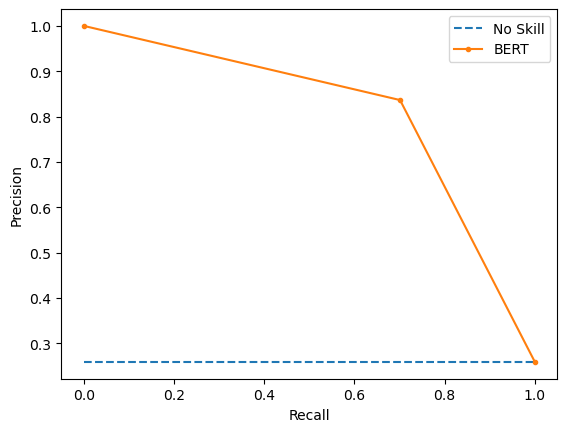

Test Loss: 0.264 | Test Acc: 88.216%
Epoch: 02 | Epoch Time: 1m 41s
	Train Loss: 0.107 | Train Acc: 95.62%
	 Val. Loss: 0.210 |  Val. Acc: 90.72%
test results for this epoch =  2
              precision    recall  f1-score   support

         0.0      0.955     0.948     0.951      2336
         1.0      0.810     0.833     0.821       624

    accuracy                          0.924      2960
   macro avg      0.883     0.891     0.886      2960
weighted avg      0.925     0.924     0.924      2960

[[2214  122]
 [ 104  520]]
0.9236486486486486
Weighted_F1 0.9240437809687724
cohen_kappa_score 0.7729371001553217
lr_precision, lr_recall [0.21081081 0.80996885 1.        ] [1.         0.83333333 0.        ]
Logistic: f1=0.821 auc=0.839
Length 624 2960
  no_skill  0.21081081081081082
                                  


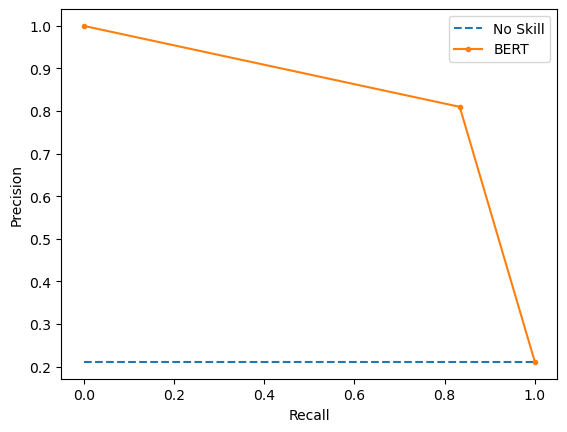

Test Loss: 0.200 | Test Acc: 92.188%
Epoch: 03 | Epoch Time: 1m 42s
	Train Loss: 0.094 | Train Acc: 96.21%
	 Val. Loss: 0.216 |  Val. Acc: 91.44%
test results for this epoch =  3
              precision    recall  f1-score   support

         0.0      0.970     0.934     0.952      2408
         1.0      0.752     0.875     0.809       552

    accuracy                          0.923      2960
   macro avg      0.861     0.904     0.880      2960
weighted avg      0.930     0.923     0.925      2960

[[2249  159]
 [  69  483]]
0.922972972972973
Weighted_F1 0.9251425661206262
cohen_kappa_score 0.761144332699103
lr_precision, lr_recall [0.18648649 0.75233645 1.        ] [1.    0.875 0.   ]
Logistic: f1=0.809 auc=0.825
Length 552 2960
  no_skill  0.1864864864864865
                                  


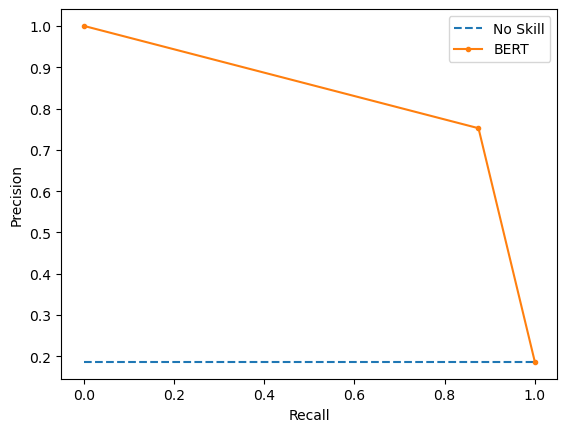

Test Loss: 0.204 | Test Acc: 92.122%
Epoch: 04 | Epoch Time: 1m 43s
	Train Loss: 0.081 | Train Acc: 96.75%
	 Val. Loss: 0.219 |  Val. Acc: 90.49%
test results for this epoch =  4
              precision    recall  f1-score   support

         0.0      0.915     0.967     0.940      2193
         1.0      0.886     0.742     0.808       767

    accuracy                          0.908      2960
   macro avg      0.900     0.854     0.874      2960
weighted avg      0.907     0.908     0.906      2960

[[2120   73]
 [ 198  569]]
0.908445945945946
Weighted_F1 0.9056533019839613
cohen_kappa_score 0.7482086199687865
lr_precision, lr_recall [0.25912162 0.88629283 1.        ] [1.         0.74185137 0.        ]
Logistic: f1=0.808 auc=0.848
Length 767 2960
  no_skill  0.2591216216216216
                                  


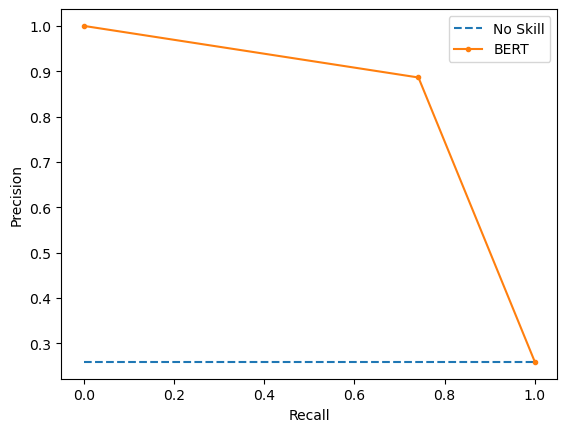

Test Loss: 0.218 | Test Acc: 90.723%
Epoch: 05 | Epoch Time: 1m 42s
	Train Loss: 0.076 | Train Acc: 97.00%
	 Val. Loss: 0.224 |  Val. Acc: 91.15%
test results for this epoch =  5
              precision    recall  f1-score   support

         0.0      0.945     0.956     0.950      2291
         1.0      0.843     0.809     0.825       669

    accuracy                          0.923      2960
   macro avg      0.894     0.882     0.888      2960
weighted avg      0.922     0.923     0.922      2960

[[2190  101]
 [ 128  541]]
0.9226351351351352
Weighted_F1 0.9220650774679109
cohen_kappa_score 0.7756658472234909
lr_precision, lr_recall [0.22601351 0.84267913 1.        ] [1.         0.80866966 0.        ]
Logistic: f1=0.825 auc=0.847
Length 669 2960
  no_skill  0.2260135135135135
                                  


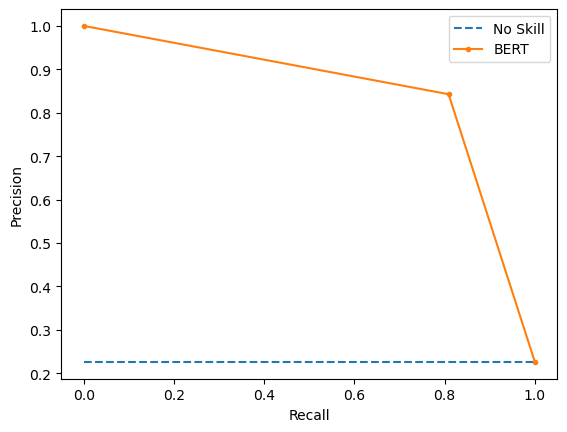

Test Loss: 0.214 | Test Acc: 92.090%
Epoch: 06 | Epoch Time: 1m 42s
	Train Loss: 0.056 | Train Acc: 97.80%
	 Val. Loss: 0.290 |  Val. Acc: 89.65%
test results for this epoch =  6
              precision    recall  f1-score   support

         0.0      0.985     0.911     0.947      2505
         1.0      0.654     0.923     0.766       455

    accuracy                          0.913      2960
   macro avg      0.820     0.917     0.856      2960
weighted avg      0.934     0.913     0.919      2960

[[2283  222]
 [  35  420]]
0.9131756756756757
Weighted_F1 0.9188927255932466
cohen_kappa_score 0.7143264861617034
lr_precision, lr_recall [0.15371622 0.65420561 1.        ] [1.         0.92307692 0.        ]
Logistic: f1=0.766 auc=0.795
Length 455 2960
  no_skill  0.15371621621621623
                                  


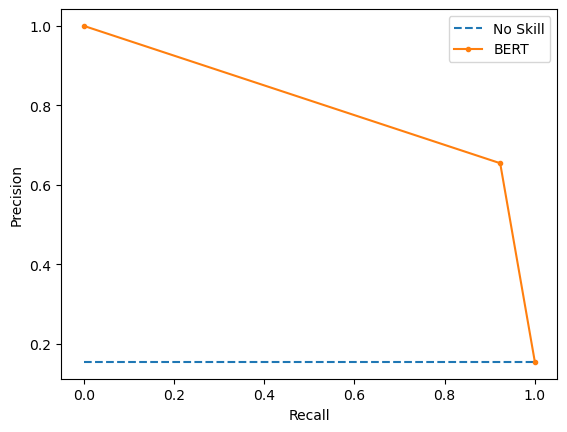

Test Loss: 0.266 | Test Acc: 91.406%
Epoch: 07 | Epoch Time: 1m 42s
	Train Loss: 0.035 | Train Acc: 98.62%
	 Val. Loss: 0.297 |  Val. Acc: 91.15%
test results for this epoch =  7
              precision    recall  f1-score   support

         0.0      0.948     0.947     0.948      2320
         1.0      0.810     0.812     0.811       640

    accuracy                          0.918      2960
   macro avg      0.879     0.880     0.880      2960
weighted avg      0.918     0.918     0.918      2960

[[2198  122]
 [ 120  520]]
0.9182432432432432
Weighted_F1 0.9182893884756473
cohen_kappa_score 0.759054948603412
lr_precision, lr_recall [0.21621622 0.80996885 1.        ] [1.     0.8125 0.    ]
Logistic: f1=0.811 auc=0.832
Length 640 2960
  no_skill  0.21621621621621623
                                  


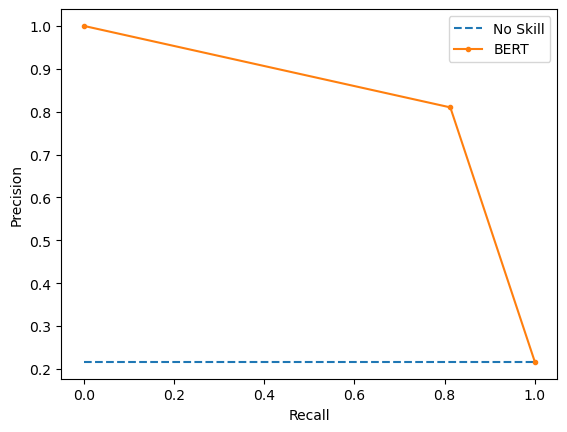

Test Loss: 0.275 | Test Acc: 91.439%
Epoch: 08 | Epoch Time: 1m 42s
	Train Loss: 0.031 | Train Acc: 98.79%
	 Val. Loss: 0.268 |  Val. Acc: 91.60%
test results for this epoch =  8
              precision    recall  f1-score   support

         0.0      0.965     0.938     0.952      2386
         1.0      0.769     0.861     0.812       574

    accuracy                          0.923      2960
   macro avg      0.867     0.899     0.882      2960
weighted avg      0.927     0.923     0.925      2960

[[2238  148]
 [  80  494]]
0.922972972972973
Weighted_F1 0.924569946221732
cohen_kappa_score 0.76422121170621
lr_precision, lr_recall [0.19391892 0.7694704  1.        ] [1.         0.86062718 0.        ]
Logistic: f1=0.812 auc=0.829
Length 574 2960
  no_skill  0.1939189189189189
                                  


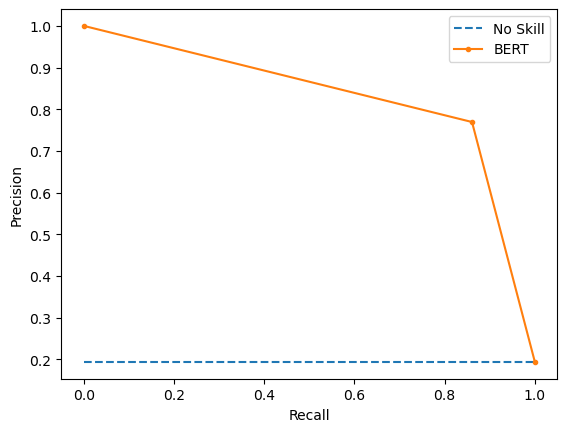

Test Loss: 0.243 | Test Acc: 92.122%


In [ ]:
import matplotlib.pyplot as plt

def my_plot(epochs, loss):
    plt.plot(epochs, loss)
    plt.title('Model Loss (BERT)')
    plt.ylabel('Loss')
    plt.xlabel('Number of Epochs')
    plt.legend(["Train",'Validation'],loc='upper right')

def my_plotACC(epochs, acc):
    plt.plot(epochs, acc)
    plt.title('Model accuracy (BERT)')
    plt.ylabel('Accuracy')
    plt.xlabel('Number of Epochs')
    plt.legend(["Train",'Validation'],loc='upper left')
N_EPOCHS = n_epoch_number

best_valid_loss = float('inf')
best_valid_acc = float('-inf')
train_loss_vals=  []
valid_loss_vals=  []

train_acc_vals=  []
valid_accs_vals=  []

for epoch in range(N_EPOCHS):
    #if (epoch > 0) and (epoch % 10 == 0):
           #reduce_lr()

    start_time = time.time()

    train_loss, train_acc = train(model, train_iterator, optimizer, criterion)
    valid_loss, valid_acc,_,_  = evaluate(model, valid_iterator, criterion)

    train_loss_vals.append(train_loss)
    valid_loss_vals.append(valid_loss)
    train_acc_vals.append(train_acc)
    valid_accs_vals.append(valid_acc)
    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
#         torch.save(model.state_dict(), 'tut6-model.pt')
        torch.save(model.state_dict(), model_file_name)
        best_epoch = epoch+1

    '''if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), 'tut6-model.pt')
        best_epoch = epoch+1 '''

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')

    #     new lines i addes to monitor test results
    print ('test results for this epoch = ', epoch+1)
    test_loss, test_acc, y_true,y_pred = evaluate(model, test_iterator, criterion)
    print(classification_report(y_true, y_pred,digits = 3))
    print(confusion_matrix(y_true, y_pred))
    print(accuracy_score(y_true, y_pred))
    print('Weighted_F1',f1_score(y_true, y_pred, average='weighted'))
    print('cohen_kappa_score',cohen_kappa_score(y_true, y_pred))

    lr_precision, lr_recall, _ = precision_recall_curve(y_true,y_pred)
    print('lr_precision, lr_recall',lr_precision, lr_recall)
    lr_f1, lr_auc = f1_score(y_true,y_pred), auc(lr_recall, lr_precision)

    print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
    # plot the precision-recall curves
    ones = [x for x in y_true if x==1]
    print('Length',len(ones),len(y_true))
    no_skill = len(ones) / len(y_true)
    print('  no_skill ', no_skill)
    print('                                  ')
    plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
    plt.plot(lr_recall, lr_precision, marker='.', label='BERT')
    # axis labels
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # show the legend
    plt.legend()
    # show the plot
    plt.show()
# end of update
    print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.3f}%')

print('Best epoch= ',best_epoch)
#my_plotACC(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), train_acc_vals)
#my_plotACC(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), valid_accs_vals)
my_plot(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), train_loss_vals)
my_plot(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), valid_loss_vals)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import cohen_kappa_score

model.load_state_dict(torch.load(model_file_name))
test_loss, test_acc, y_true,y_pred = evaluate(model, test_iterator, criterion)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.3f}%')
print(classification_report(y_true, y_pred,digits = 3))

print(confusion_matrix(y_true, y_pred))
print(accuracy_score(y_true, y_pred))
print('Weighted_F1',f1_score(y_true, y_pred, average='weighted'))
print('cohen_kappa_score',cohen_kappa_score(y_true, y_pred))

lr_precision, lr_recall, _ = precision_recall_curve(y_true,y_pred)
print('lr_precision, lr_recall',lr_precision, lr_recall)
lr_f1, lr_auc = f1_score(y_true,y_pred), auc(lr_recall, lr_precision)

print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
# plot the precision-recall curves
ones = [x for x in y_true if x==1]
print('Length',len(ones),len(y_true))
no_skill = len(ones) / len(y_true)
print('  no_skill ', no_skill)
print('                                  ')
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(lr_recall, lr_precision, marker='.', label='BERT')
# axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
# show the legend
plt.legend()
# show the plot
plt.show()
